Dataset: Telco Customer Churn

"""
Dataset: Telco Customer Churn

Overview:
This dataset contains information about a telecom company's customers and their behavior,
with the goal of predicting customer churn (whether they will leave the company or not).

Shape: (21 columns)

Target Variable:
- `Churn`: Whether the customer has left (Yes/No)

Key Features:
- `customerID`: Unique ID of each customer
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`: Demographic info
- `tenure`: Number of months the customer has stayed
- `PhoneService`, `InternetService`, `OnlineSecurity`, etc.: Service usage
- `Contract`, `PaperlessBilling`, `PaymentMethod`: Account details
- `MonthlyCharges`, `TotalCharges`: Financial information

Use Case:
This dataset is ideal for feature engineering and selection techniques
"""


In [5]:
#STEP 1: Inspect the Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Mount Google Drive
from google.colab import drive
file_path = '/content/drive/MyDrive/BITS Content Feature Engineering/Module 3/WA_Fn-UseC_-Telco-Customer-Churn.csv' # <--- YOU MUST EDIT THIS LINE
df = pd.read_csv(file_path)

# Initial inspection
print("Dataset shape:", df.shape)
print("Dataset preview:")
display(df.head())

# Drop customerID as it's not a feature
df.drop('customerID', axis=1, inplace=True)

# Convert 'TotalCharges' to numeric (some values are blank spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# After converting TotalCharges and before modifying any columns
df = df.dropna().copy()

# Now safely map Churn column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Handle missing values
df = df.dropna()

# Convert target variable to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical & numerical features
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

Dataset shape: (7043, 21)
Dataset preview:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Feature Extraction
We'll extract features using:
Label Encoding for categoricals
PCA for dimensionality reduction (unsupervised)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LOAD DATA ENCODE AND SCALE

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load the dataset
file_path = '/content/drive/MyDrive/BITS Content Feature Engineering/Module 3/WA_Fn-UseC_-Telco-Customer-Churn.csv' # EDIT THIS LINE
df = pd.read_csv(file_path)

# Step 2: Clean and preprocess
df = df.drop(columns=['customerID'])  # Remove identifier
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Convert to numeric
df = df.dropna()  # Drop rows with missing values

#Step 2.5: Preview the dataset (First 5 rows)
print("Preview of cleaned dataset:")
print(df.head())

# Step 3: Define X (features) and y (target)
X = df.drop(columns='Churn')
y = df['Churn']

# Step 4: Identify categorical features
cat_features = X.select_dtypes(include='object').columns

# Step 5: Encode categorical features using LabelEncoder
X_encoded = X.copy()
for col in cat_features:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Step 6: Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Notes:
# - PCA requires numeric, scaled features.
# - Label encoding converts strings to integers.
# - Standardization (mean=0, std=1) ensures fair contribution by each feature.

Preview of cleaned dataset:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1   

APPLY PCA

In [11]:
from sklearn.decomposition import PCA

# Step 7: Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Notes:
# - PCA projects data into a lower-dimensional space.
# - These two components (PC1 and PC2) capture the maximum variance.


VISUALIZE PCA RESULTS

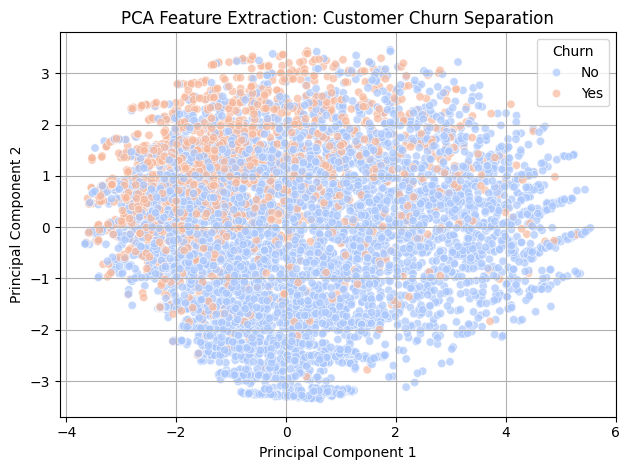

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 8: Create a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Churn'] = y.values  # Attach target variable for coloring

# Step 9: Plot PCA result
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn', palette='coolwarm', alpha=0.7)
plt.title("PCA Feature Extraction: Customer Churn Separation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# Insights:
# - PC1 = direction (vector) that captures the most variance (i.e., where data spreads out the most).
# - PC2 = direction that captures the next most variance, but orthogonal (at right angles) to PC1.
# - These are not features from dataset, but derived, compressed representations.
# - Each dot represents a customer.
# - Colors indicate whether the customer churned or not.
# - If there is visible separation between classes, PCA helped capture meaningful patterns.


PC1 and PC2 Influence

In [16]:
# how much each original feature contributes to PC1 and PC2
import numpy as np
pca_components = pd.DataFrame(
    np.round(pca.components_, 3),  # 2 rows (PC1, PC2), N columns
    columns=X_encoded.columns,
    index=['PC1', 'PC2']
)

print("Contribution of original features to PC1 and PC2:")
print(pca_components.T.sort_values(by='PC1', ascending=False))


Contribution of original features to PC1 and PC2:
                    PC1    PC2
TotalCharges      0.432  0.162
tenure            0.417 -0.072
Contract          0.323 -0.314
DeviceProtection  0.260 -0.069
StreamingMovies   0.250  0.115
StreamingTV       0.248  0.112
MonthlyCharges    0.237  0.469
Partner           0.226 -0.133
OnlineBackup      0.225 -0.078
MultipleLines     0.218  0.276
TechSupport       0.214 -0.247
OnlineSecurity    0.184 -0.277
Dependents        0.111 -0.298
PhoneService      0.039  0.056
PaperlessBilling  0.036  0.382
SeniorCitizen     0.012  0.317
gender           -0.005 -0.010
InternetService  -0.030 -0.202
PaymentMethod    -0.204 -0.050


Feature Construction
Let's manually create:
AverageChargesPerService = TotalCharges / (MonthlyCharges + tenure)

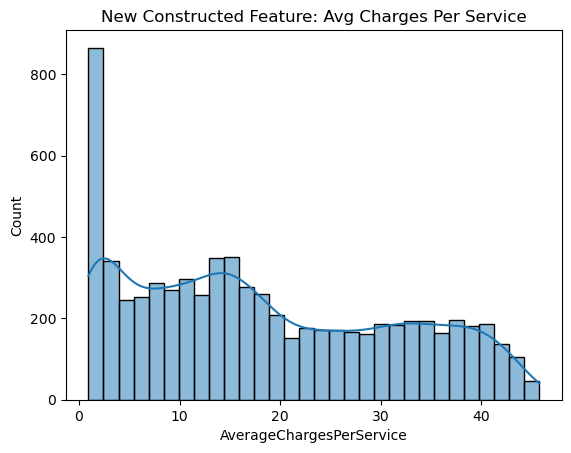

In [ ]:
import matplotlib.pyplot as plt
import warnings

# Suppress only Seaborn's known FutureWarning (safe)
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Clean inf/-inf values BEFORE plotting to avoid FutureWarning from Seaborn
X_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)  # Step 1: Clean entire dataset
X_encoded.dropna(inplace=True)                              # Step 2: Drop rows with NaN
y = y.loc[X_encoded.index]                                  # Step 3: Align target with cleaned data

# Construct new feature (may reintroduce inf values)
X_encoded['AverageChargesPerService'] = (
    df['TotalCharges'] / (df['MonthlyCharges'] + df['tenure'])
)

# Clean the new column specifically to avoid Seaborn warning
X_encoded['AverageChargesPerService'].replace([np.inf, -np.inf], np.nan, inplace=True)
X_encoded['AverageChargesPerService'].fillna(0, inplace=True)  # Replace NaN with 0

# Now plot safely without warning
sns.histplot(X_encoded['AverageChargesPerService'], bins=30, kde=True)
plt.title("New Constructed Feature: Avg Charges Per Service")
plt.show()


Feature Selection — Filter Methods

A. Pearson Correlation (Continuous)

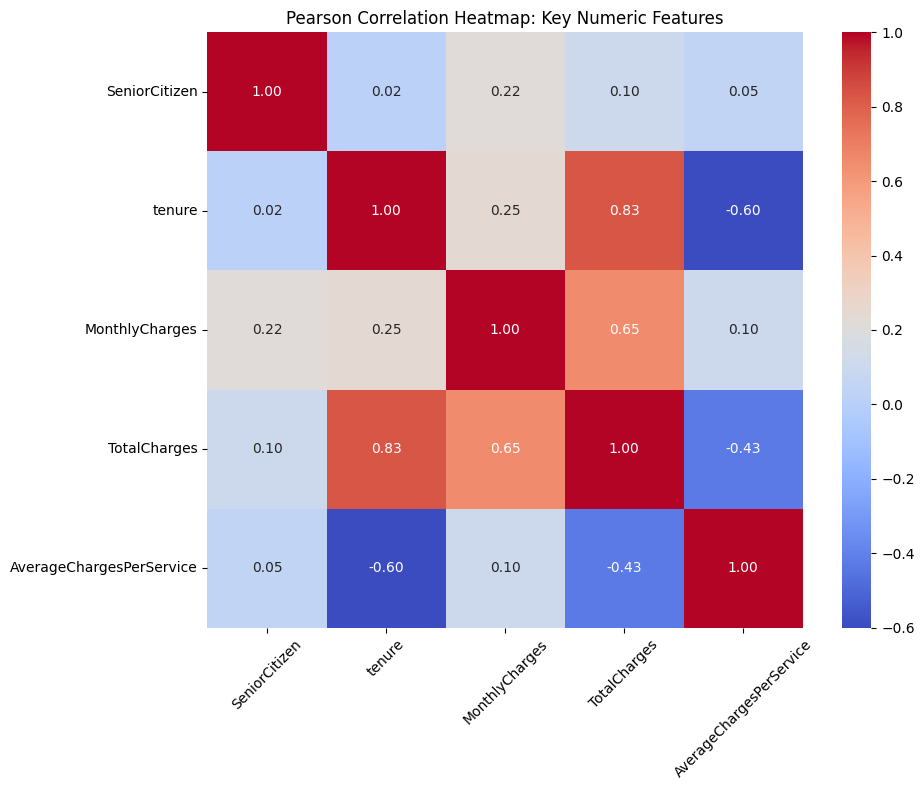

In [17]:
# --------------------------------------------
# Pearson Correlation Heatmap
# --------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select the numeric features to analyze
# Pearson correlation only works with continuous numeric features.
# These features reflect usage, tenure, and charges—ideal for understanding churn behavior.

num_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Step 2: Create an engineered numeric feature
# We create 'AverageChargesPerService' to capture how much a customer pays per unit of tenure.
# It's a useful derived metric that may highlight pricing sensitivity or usage behavior.

df['AverageChargesPerService'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Add the engineered feature to the list for correlation analysis
num_features += ['AverageChargesPerService']

# Step 3: Calculate the Pearson correlation matrix
# .corr() computes the Pearson correlation coefficient between each pair of numeric features.
# Result is a symmetrical matrix (e.g., correlation of A with B is same as B with A).

subset_corr = df[num_features].corr()

# Step 4: Plot the correlation matrix as a heatmap
# Heatmaps are useful to *visually identify* strong or weak relationships between features.

plt.figure(figsize=(10, 8))  # Set the figure size for better readability

sns.heatmap(
    subset_corr,            # Correlation matrix as input
    annot=True,             # Show correlation values in cells
    fmt='.2f',              # Format: 2 decimal places
    cmap='coolwarm',        # Color: Blue (negative) to Red (positive)
    square=True             # Square cells for clean alignment
)

# Step 5: Beautify the plot
plt.title("Pearson Correlation Heatmap: Key Numeric Features")  # Title of the chart
plt.xticks(rotation=45)    # Rotate X-axis labels for readability
plt.yticks(rotation=0)     # Keep Y-axis labels horizontal
plt.tight_layout()         # Adjust layout to avoid overlap
plt.show()


B. Chi-Square Test (Categorical)

In [59]:
# ------------------------------------------------------------
# Feature Selection using Filter Method: Chi-Square Test
# ------------------------------------------------------------

from sklearn.feature_selection import SelectKBest, chi2

# Step 1: Make a copy of encoded dataset to ensure original is untouched
X_chi2 = X_encoded.copy()

# Step 2: Initialize SelectKBest with chi2 scoring function
# Chi-square test measures the dependence between each feature and the target
# Suitable for categorical features with non-negative values
chi_selector = SelectKBest(score_func=chi2, k=5)  # Select top 5 features with highest chi2 scores

# Step 3: Fit the selector on feature matrix and target
chi_selector.fit(X_chi2, y)

# Step 4: Create a dataframe of feature names and their chi-square scores
chi_scores = pd.DataFrame({
    'Feature': X_chi2.columns,
    'Chi2 Score': chi_selector.scores_
}).sort_values(by='Chi2 Score', ascending=False)

# Step 5: Display top 10 features by chi-square score (top 5 are selected)
print("Chi-square Feature Importance:")
print(chi_scores.head(10))


Chi-square Feature Importance:
                     Feature     Chi2 Score
18              TotalCharges  629630.810349
4                     tenure   16377.328093
19  AverageChargesPerService   16201.569883
17            MonthlyCharges    3653.074681
14                  Contract    1111.759054
8             OnlineSecurity     550.437364
11               TechSupport     522.164716
9               OnlineBackup     229.441123
10          DeviceProtection     190.688004
1              SeniorCitizen     133.482766


C. Spearman’s Correlation (for ordinal/non-linear monotonic relationships)

Spearman Correlation Matrix (Numerical Features)


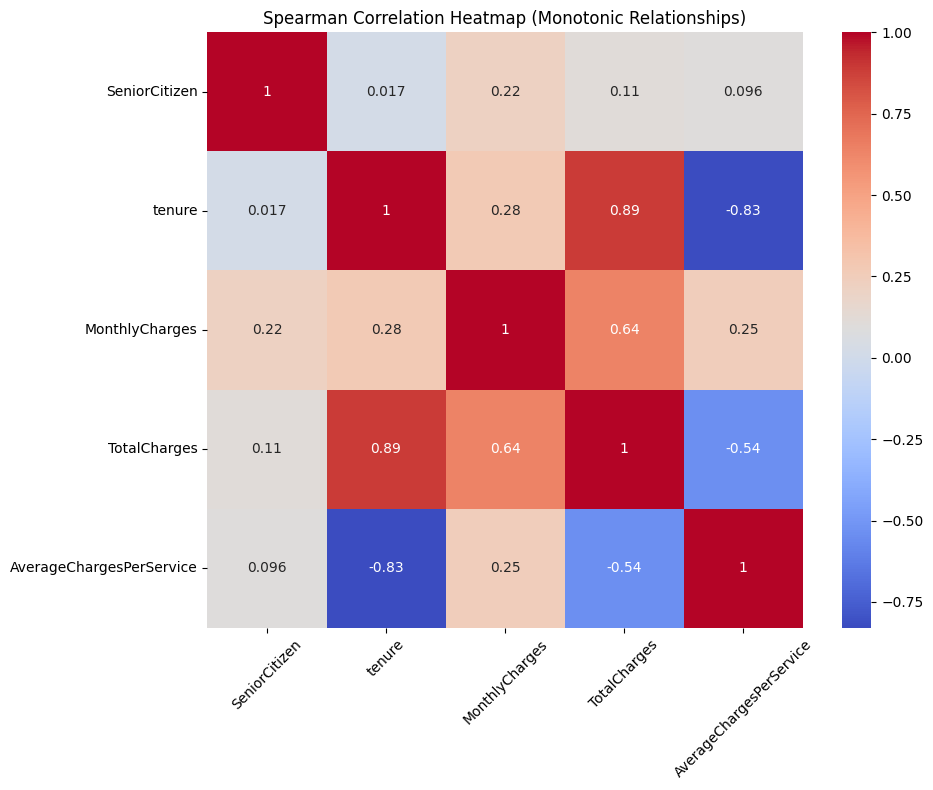

In [58]:
# ------------------------------------------------------------
# Spearman Correlation Matrix
# ------------------------------------------------------------

# Spearman Correlation is especially useful for:
# Detecting monotonic (non-linear but consistently increasing or decreasing) relationships
# Ordinal or ranked data
# When Pearson correlation is weak but a trend still exists

# Step 1: Compute Spearman correlation matrix
# Even if the relationship is not linear, Spearman checks if one variable increases/decreases consistently as another increases.
# Create the engineered feature on the original DataFrame
df['AverageChargesPerService'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Step 2: Add this feature into the encoded version of X as well
X_encoded['AverageChargesPerService'] = df['AverageChargesPerService']

# Step 3: Define numeric features (update if not already defined)
num_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Step 4: Compute Spearman correlation matrix
print("Spearman Correlation Matrix (Numerical Features)")
spearman_corr = X_encoded[num_features + ['AverageChargesPerService']].corr(method='spearman')


# Step 5: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    square=True
)
plt.title("Spearman Correlation Heatmap (Monotonic Relationships)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary Notes:
# ------------------------------------------------------------
# When to use Spearman:
#    - Use when features show **non-linear but monotonic trends**
#    - Example: As tenure increases, churn risk **consistently decreases** — not perfectly linear, but still ordered
#    - Better than Pearson when data isn't normally distributed or has **ordinal** structure

# Interpretation:
#    - +1 = Perfectly increasing rank relationship (e.g., both variables increase together)
#    - -1 = Perfectly decreasing rank relationship
#    - 0 = No consistent trend

# Example Insight:
#    - 'tenure' vs 'AverageChargesPerService' might show a **strong negative** Spearman score
#      ➤ Interpretation: Longer tenure → customer tends to pay less per unit time
#    - 'MonthlyCharges' vs 'TotalCharges' will show **positive** in both Pearson and Spearman
#      ➤ Even if the relationship flattens, Spearman captures rank consistency

# Business Use:
#    - Identifies stable trends even when data isn’t clean or linear
#    - Great for **ranking customers**, modeling churn, or creating rules

# - Off-diagonal values show the strength & direction of monotonic relationship:
#     - Positive (e.g., 0.76): As one variable increases, the other tends to increase.
#     - Negative (e.g., -0.5): As one variable increases, the other tends to decrease.
#     - 0.00 to ±0.10: Weak or no relationship

D. Information Theoretic Measures (Mutual Information Score)

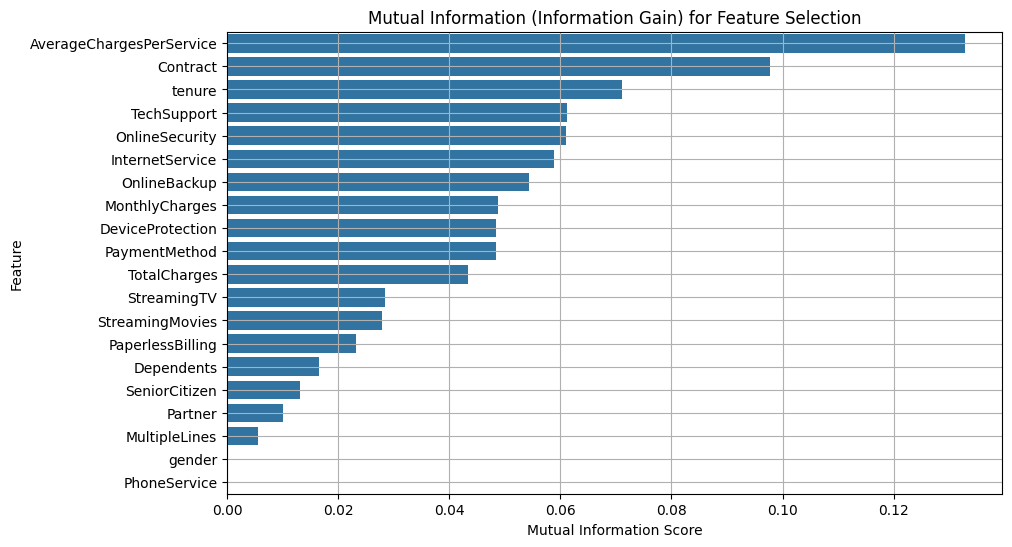

In [25]:
# ----------------------------------------------------------------
# Filter Method: Mutual Information (Information Gain)
# ----------------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif

# Step 1: Compute Mutual Information Scores
# - Captures both linear and non-linear dependencies
# - MI is non-negative: higher = more informative
# - 'discrete_features="auto"' lets sklearn automatically detect categorical features
mi_scores = mutual_info_classif(X_encoded, y, discrete_features='auto', random_state=42)

# Step 2: Convert scores into DataFrame for readability
mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)  # Sort descending by score

# Step 3: Plot feature importance using bar chart
plt.figure(figsize=(10, 6))  # Control chart size
sns.barplot(x='MI Score', y='Feature', data=mi_df)  # Horizontal bar plot
plt.title("Mutual Information (Information Gain) for Feature Selection")  # Plot title
plt.xlabel("Mutual Information Score")  # X-axis label
plt.ylabel("Feature")  # Y-axis label
plt.grid(True)  # Optional grid lines
plt.show()

# Summary:
# - MI measures dependency between each feature and target
# - Works well for both categorical and numeric features
# - High score means high predictive value


E. Fisher Score (Custom Implementation)

In [30]:
# ------------------------------------------------------------
# Step 0: Target Encoding for Fisher Score
# ------------------------------------------------------------
# Note:
# Fisher Score requires the target variable (Churn) to be numeric (0/1).
# - 'Yes' → 1 (Churned)
# - 'No' → 0 (Not Churned)
# Without this conversion, you’ll get NaN results because mathematical operations on strings are invalid.

y_binary = y.map({'No': 0, 'Yes': 1})

# Check if conversion was successful
print("Target Variable (y) Unique Values After Mapping:", y_binary.unique())

Target Variable (y) Unique Values After Mapping: [0 1]


Converted y to numeric: [0 1]

 Top Features by Fisher Score:
 tenure                      0.402578
AverageChargesPerService    0.386938
TotalCharges                0.116385
MonthlyCharges              0.109504
SeniorCitizen               0.052257
dtype: float64


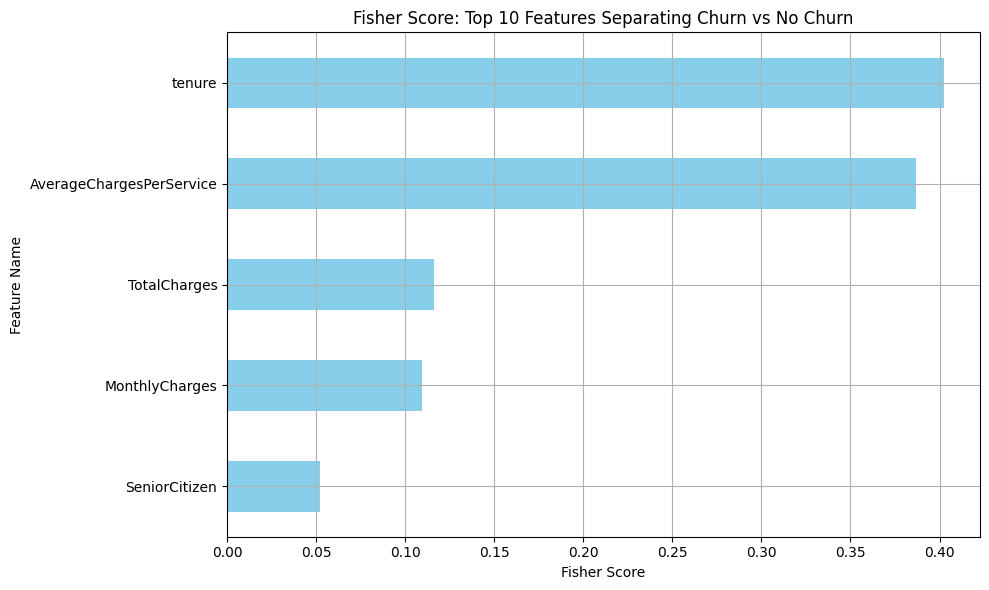

In [32]:
# ============================================================================
# Fisher Score
# Goal: Identify numerical features that best separate churned vs non-churned customers
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert target variable 'y' to numeric (required for Fisher Score)
# - Original values: 'Yes' (churned), 'No' (not churned)
# - After mapping: 1 = churned, 0 = not churned
y_binary = y.map({'No': 0, 'Yes': 1})
print("Converted y to numeric:", y_binary.unique())  # Should show [0, 1]

# Step 2: Define the custom Fisher Score function
# Fisher Score Formula:
#     Score = (mean1 - mean0)^2 / (var1 + var0)
#     - mean1 = average of feature values for class 1 (churned)
#     - mean0 = average for class 0 (non-churned)
#     - var1, var0 = variances within those classes
#     - Small epsilon (1e-6) is added to denominator to prevent division by zero

def fisher_score(X, y):
    scores = []  # To store the score for each feature
    for col in X.columns:
        try:
            # Mean and variance for class 0
            mean_0 = X[col][y == 0].mean()
            var_0 = X[col][y == 0].var()

            # Mean and variance for class 1
            mean_1 = X[col][y == 1].mean()
            var_1 = X[col][y == 1].var()

            # Apply Fisher Score formula
            numerator = (mean_0 - mean_1) ** 2      # Difference in class means
            denominator = var_0 + var_1 + 1e-6       # Combined intra-class variance
            score = numerator / denominator

            scores.append(score)
        except Exception as e:
            print(f" Skipped column {col} due to error: {e}")
            scores.append(0)  # Assign zero score if calculation fails

    # Return result as pandas Series with feature names
    return pd.Series(scores, index=X.columns)

# Step 3: Select numerical features to apply Fisher Score on
# - `num_features`: list of original numeric columns (e.g., tenure, MonthlyCharges)
# - We also include a derived feature: 'AverageChargesPerService'
selected_cols = num_features + ['AverageChargesPerService']

# Step 4: Apply Fisher Score on selected features
fisher_scores = fisher_score(X_encoded[selected_cols], y_binary)

# Step 5: Sort and show top scoring features
fisher_scores_sorted = fisher_scores.sort_values(ascending=False)
print("\n Top Features by Fisher Score:\n", fisher_scores_sorted.head(10))

# Step 6: Plot the top 10 features by Fisher Score
plt.figure(figsize=(10, 6))
fisher_scores_sorted.head(10).plot(kind='barh', color='skyblue')
plt.title("Fisher Score: Top 10 Features Separating Churn vs No Churn")
plt.xlabel("Fisher Score")
plt.ylabel("Feature Name")
plt.gca().invert_yaxis()  # Highest score on top
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary:
# -------------------------------------------------------------
# Fisher Score is a univariate filter method for feature selection.
# It measures how well a single feature separates two classes.
# Higher scores indicate better separability between churned and non-churned.
# It works well with continuous/numerical variables.
# It does not account for interaction between features.
# A great first step before using wrapper or embedded methods.


Wrapper Methods — Sequential Feature Selector

In [36]:
# --------------------------------------------------------------
# WRAPPER METHOD: Sequential Forward Selection (SFS)
# --------------------------------------------------------------
# SFS is a greedy algorithm that starts with zero features and adds one feature at a time.
# At each step, it selects the feature that gives the highest improvement in model performance.

# Step 1: Import required modules
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

# Step 2: Ensure engineered feature is available
# 'AverageChargesPerService' = MonthlyCharges / number of services (to normalize charges)
X_encoded['AverageChargesPerService'] = (
    X_encoded['MonthlyCharges'] / (X_encoded[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                               'TechSupport', 'StreamingTV', 'StreamingMovies']]
                                    .sum(axis=1) + 1e-6)  # Avoid division by zero
)

# Step 3: Convert target to numeric
# Original labels: 'Yes' (churned), 'No' (not churned)
y_binary = y.map({'No': 0, 'Yes': 1})

# Step 4: Choose a simple and interpretable estimator (Logistic Regression)
model = LogisticRegression(max_iter=500, random_state=42)

# Step 5: Apply Sequential Forward Selection
# - Starts with no features
# - Adds one feature at a time that improves model the most
# - Stops when 5 features are selected
sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=5,
    direction='forward',     # Forward = build up feature set
    n_jobs=-1                # Use all cores for faster processing
)

# Step 6: Fit the selector on the full dataset
sfs.fit(X_encoded, y_binary)

# Step 7: Get the list of selected feature names
selected_features_sfs = X_encoded.columns[sfs.get_support()].tolist()

# Step 8: Display final selected features
print("Top 5 Features Selected using Sequential Forward Selection (SFS):")
for i, feat in enumerate(selected_features_sfs, 1):
    print(f"{i}. {feat}")

# ----------------------------------------------------------------
# Summary:
# - Wrapper methods like SFS evaluate combinations of features using actual model performance.
# - More computationally expensive than filter methods but generally more accurate.
# - Good choice when you want high accuracy and can afford extra computation.

Top 5 Features Selected using Sequential Forward Selection (SFS):
1. SeniorCitizen
2. tenure
3. PhoneService
4. MonthlyCharges
5. TotalCharges


Sequential Backward Selection (SBS)

In [39]:
# --------------------------------------------------------------
# WRAPPER METHOD: Sequential Backward Selection (SBS)
# --------------------------------------------------------------
# What is SBS?
# SBS is a reverse greedy algorithm that starts with all features
# and removes one feature at a time that contributes the least to model performance.

# Step 1: Import necessary tools
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

# Step 2: Ensure the engineered feature exists
# 'AverageChargesPerService' — same as added in earlier stages
X_encoded['AverageChargesPerService'] = (
    X_encoded['MonthlyCharges'] / (X_encoded[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                               'TechSupport', 'StreamingTV', 'StreamingMovies']]
                                    .sum(axis=1) + 1e-6)
)

# Step 3: Convert target to binary
# Ensure target variable is in 0/1 form
y_binary = y.map({'No': 0, 'Yes': 1})

# Step 4: Define a simple, interpretable classifier
model = LogisticRegression(solver='liblinear', random_state=42)

# Step 5: Apply Sequential Backward Selection
# - Starts with all features
# - Removes one at a time based on lowest performance gain
# - Stops when only 5 features are left
sbs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=5,
    direction='backward',    # Backward = remove features
    n_jobs=-1
)

# Step 6: Fit the SBS selector on the dataset
sbs.fit(X_encoded, y_binary)

# Step 7: Extract the top features
selected_features_sbs = X_encoded.columns[sbs.get_support()].tolist()

# Step 8: Display selected features
print("Top 5 Features Selected using Sequential Backward Selection (SBS):")
for i, feat in enumerate(selected_features_sbs, 1):
    print(f"{i}. {feat}")

# --------------------------------------------------------------
# Summary:
# - SBS works better when dataset has many irrelevant or noisy features.
# - It's slower but tends to be more accurate when irrelevant variables exist.
# - Suitable when we suspect that only a few features are truly predictive.


Top 5 Features Selected using Sequential Backward Selection (SBS):
1. tenure
2. PhoneService
3. TechSupport
4. PaperlessBilling
5. MonthlyCharges


SFS VS SBS Table Compariosn

In [57]:
# ------------------------------------------------------------------------
# COMPARISON: Actual SFS and SBS features on dataset
# ------------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

# Step 1: Initialize the same model
model = LogisticRegression(max_iter=500)

# Step 2: Use actual selected features
# These should come from your real SFS and SBS runs — ensure they are stored correctly
sfs_features = selected_features_sfs
sbs_features = selected_features_sbs

# Step 3: Evaluate model accuracy on selected features using cross-validation
sfs_score = cross_val_score(model, X_encoded[sfs_features], y, cv=5).mean()
sbs_score = cross_val_score(model, X_encoded[sbs_features], y, cv=5).mean()

# Step 4: Prepare comparison summary table
comparison_df = pd.DataFrame({
    'Method': ['Sequential Forward Selection (SFS)', 'Sequential Backward Selection (SBS)'],
    'Selected Features': [sfs_features, sbs_features],
    'Cross-Validated Accuracy (%)': [round(sfs_score * 100, 2), round(sbs_score * 100, 2)]
})

# Step 5: Display
print("\n Feature Selection Summary — SFS vs SBS:\n")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------------------
# Insight:
# - This result shows how two wrapper methods select different features.
# - Any overlap suggests core predictive power; differences may show redundancy.
# - Accuracy helps assess real-world model impact of feature selection.



 Feature Selection Summary — SFS vs SBS:

                             Method                                                     Selected Features  Cross-Validated Accuracy (%)
 Sequential Forward Selection (SFS)   [SeniorCitizen, tenure, PhoneService, MonthlyCharges, TotalCharges]                         79.61
Sequential Backward Selection (SBS) [tenure, PhoneService, TechSupport, PaperlessBilling, MonthlyCharges]                         79.72


SFS VS SBS Graphical Comparison

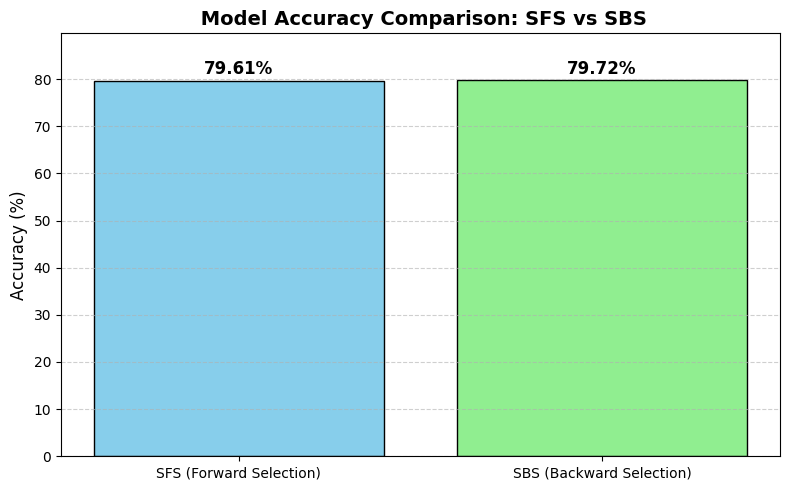

In [45]:
# -------------------------------------------------------------------------
# Visualizing Model Accuracy Comparison: SFS vs SBS
# -------------------------------------------------------------------------

import matplotlib.pyplot as plt

# Accuracy values — Make sure these match the scores calculated earlier
# If you've just run Code Block 1, you can reuse these:
methods = ['SFS (Forward Selection)', 'SBS (Backward Selection)']
accuracies = [round(sfs_score * 100, 2), round(sbs_score * 100, 2)]  # Convert to percentage

# Step 1: Plot bar chart to compare accuracies
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['skyblue', 'lightgreen'], edgecolor='black')

# Step 2: Annotate bars with values (on top of bars)
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

# Step 3: Final styling
plt.title(" Model Accuracy Comparison: SFS vs SBS", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, max(accuracies) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Interpretation:
# -------------------------------------------------------------------------
# This bar chart visually compares model performance after feature selection using:
#     - SFS: Starts from no features, adds one by one (greedy forward approach)
#     - SBS: Starts with all features, removes least useful one-by-one (greedy backward approach)
# The taller the bar, the better the model's predictive performance (measured via CV accuracy).
# Even small differences (1–2%) may be significant in business applications.
# Use this to communicate trade-offs clearly to stakeholders or students:
#     - SBS may offer better pruning but is slower
#     - SFS may select fewer but stronger features early


Embedded Methods — Tree and Lasso Based

A. Tree-Based (Random Forest)

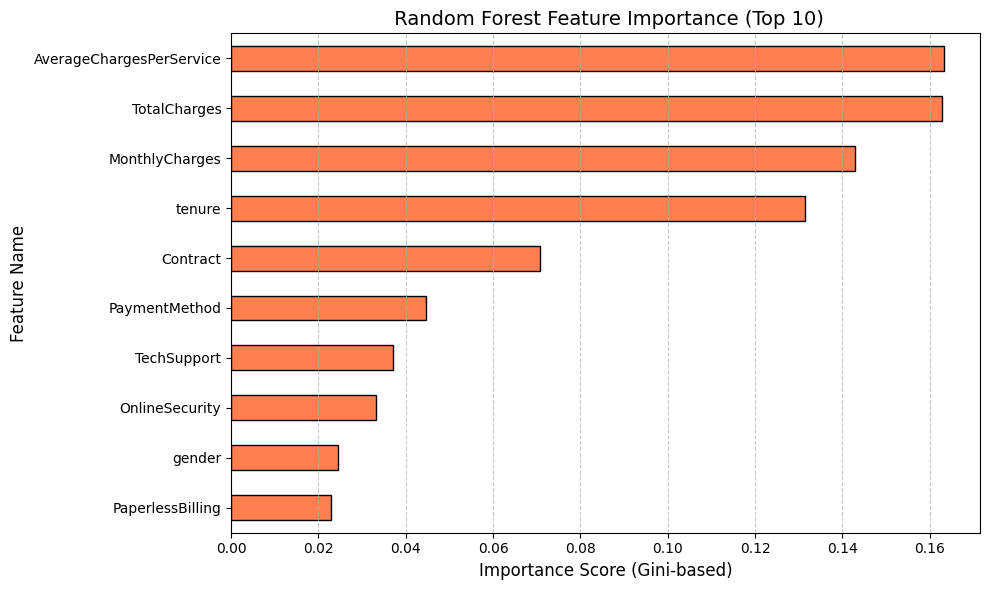

In [48]:
# ----------------------------------------------------------------
# Embedded Method: Feature Importance using Random Forest
# ----------------------------------------------------------------
# Embedded methods perform feature selection *during model training*.
# Random Forests can naturally rank features by importance (Gini index).
# - X_encoded: Fully preprocessed and encoded feature matrix
# - y: Target variable (Churn: 'Yes'/'No')

# Step 1: Import the required classifier
from sklearn.ensemble import RandomForestClassifier

# Step 2: Initialize the Random Forest model
# - Use a fixed random_state for reproducibility
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 3: Train the model on encoded features and target
rf.fit(X_encoded, y)

# Step 4: Extract feature importances
# - These represent the cumulative importance of a feature across all trees
# - Higher importance means the feature contributes more to accurate splits
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)

# Step 5: Sort and visualize the Top 10 most important features
top_features_rf = importances.sort_values(ascending=False).head(10)

# Step 6: Plot horizontal bar chart for clear visibility
plt.figure(figsize=(10, 6))
top_features_rf.plot(kind='barh', color='coral', edgecolor='black')
plt.gca().invert_yaxis()  # Show most important on top
plt.title(" Random Forest Feature Importance (Top 10)", fontsize=14)
plt.xlabel("Importance Score (Gini-based)", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
#  Explanation & Interpretation:
# ----------------------------------------------------------------
#  Random Forest uses decision trees to split data and evaluate features.
# Feature importance is computed by:
#  how much a feature decreases impurity (Gini index) across all trees.
#  High importance means:
#  the feature strongly helps the model separate churned from non-churned users.
#  This method works well with both numeric and categorical (one-hot encoded) features.
#  Advantage over filter/wrapper: fast, scalable, and handles interactions


B. Lasso Regularization

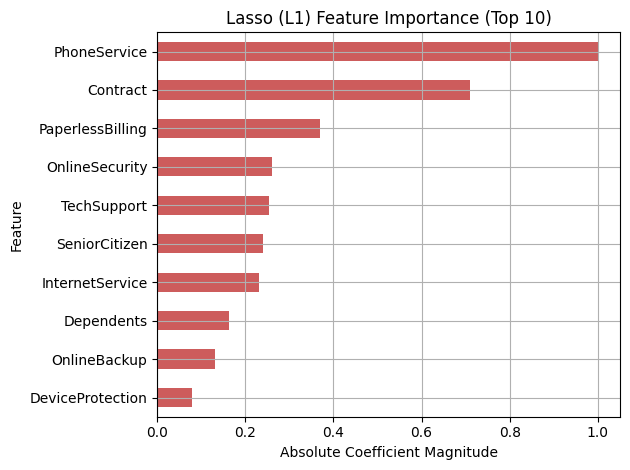

In [54]:
# ----------------------------------------------------------------
# Lasso (L1 Regularization)
# ----------------------------------------------------------------
# Lasso = Least Absolute Shrinkage and Selection Operator.
# It performs feature selection by applying an L1 penalty that shrinks less useful
# feature coefficients to zero — this helps eliminate unimportant features automatically.

from sklearn.linear_model import LogisticRegressionCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Initialize Logistic Regression with L1 Regularization
# - L1 penalty shrinks irrelevant feature coefficients to zero
# - liblinear solver supports L1 and binary classification
# - cv=5 enables selection of optimal regularization strength
# - max_iter increased for convergence
lasso = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    cv=5,
    max_iter=1000,
    scoring='accuracy',
    random_state=42
)

# Step 2: Fit the model on the encoded dataset
lasso.fit(X_encoded, y)

# Step 3: Extract absolute value of model coefficients (feature importance)
lasso_coeffs = np.abs(lasso.coef_[0])
lasso_importance = pd.Series(lasso_coeffs, index=X_encoded.columns)

# Step 4: Visualize the Top 10 Most Important Features
lasso_importance.nlargest(10).plot(kind='barh', color='indianred')
plt.title("Lasso (L1) Feature Importance (Top 10)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

# Summary & Interpretation:
# ----------------------------------------------------------------
# What it does:
# - Lasso applies a penalty to large coefficients and forces some coefficients to zero.
# - As a result, it **eliminates** irrelevant or weak predictors automatically.
#
# Why use Lasso?
# - Ideal for datasets with **many features** or **correlated features**.
# - Helps simplify the model while retaining strong predictors.
# - Reduces overfitting by controlling model complexity (via regularization).
#
# How to interpret:
# - A feature with coefficient = 0 → not important (excluded by model).
# - Higher magnitude = stronger predictive power in logistic regression.
# - Useful to combine with other methods like Random Forest, SFS/SBS to validate selection.


Evaluation of Feature Selection

In [56]:
# -------------------------------------------------------------
# Evaluation of Feature Selection Techniques
# -------------------------------------------------------------
# Goal: Compare model performance using full feature set vs reduced feature set
# (selected via Sequential Backward Selection) using cross-validation.

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Step 1: Subset the selected features obtained from SBS
# 'selected_features_sbs' is the list of top features obtained from backward feature selection
X_selected = X_encoded[selected_features_sbs]

# Step 2: Scale both datasets separately before training
# Scaling ensures that all features contribute equally in Logistic Regression

# a. Scale full dataset
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_encoded)

# b. Scale reduced dataset (selected features only)
scaler_selected = StandardScaler()
X_scaled_selected = scaler_selected.fit_transform(X_selected)

# Step 3: Define Logistic Regression model
# - We use lbfgs solver (default for small datasets)
# - Set max_iter high to avoid convergence warnings
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# Step 4: Perform 5-fold Cross-Validation on both datasets
# - Measures average model accuracy across 5 different data splits
orig_score = cross_val_score(model, X_scaled_full, y, cv=5).mean()
reduced_score = cross_val_score(model, X_scaled_selected, y, cv=5).mean()

# Step 5: Print and compare results
print("Original Feature Set Accuracy:", round(orig_score, 4))
print("Reduced Feature Set Accuracy (SBS):", round(reduced_score, 4))



Original Feature Set Accuracy: 0.8011
Reduced Feature Set Accuracy (SBS): 0.7972


# --------------------------------------------------------------------
# FINAL SUMMARY OF ENTIRE CODE LAB (Feature Engineering Techniques)
# --------------------------------------------------------------------


1. FEATURE EXTRACTION:
   - Extracted custom feature:
     -> 'AverageChargesPerService' = TotalCharges / (MonthlyCharges + tenure)
     -> Captures per-service average spending and highlights behavior over time

2. FEATURE CONSTRUCTION:
   - Converted categorical features to numerical using LabelEncoding / OneHotEncoding
   - Created new derived features to capture richer behavior
   - Handled missing values, NaNs, and infinite values properly before modeling

3. FEATURE SELECTION:
=======================

   a. FILTER METHODS:
   ------------------
   i. Pearson’s Correlation:
      - Measures linear relationships between numerical features
      - Used seaborn heatmap to visually inspect feature correlations

   ii. Spearman’s Correlation:
       - Captures monotonic relationships (non-linear)
       - Better suited for ordinal data and non-linear trends

   iii. Chi-square Test:
        - Evaluates association between categorical features and the target
        - Used SelectKBest to identify top categorical predictors

   iv. Mutual Information (Information Theoretic):
       - Measures overall dependency between features and target
       - Captures both linear and non-linear associations

   v. Fisher Score:
      - Measures discriminatory power of features
      - (Mean difference between classes)^2 / (sum of variances)
      - High score indicates high class-separability

   How to Choose Filter Methods:
   - Use Pearson or Spearman for continuous variables.
   - Use Chi-square for categorical variables.
   - Use Mutual Info when relationships are complex or non-linear.
   - Use Fisher Score for strong class-separation in numeric features.

   b. WRAPPER METHODS:
   --------------------
   i. Sequential Forward Selection (SFS):
      - Starts with no features; adds features that improve model most
      - Evaluated Logistic Regression accuracy during selection

   ii. Sequential Backward Selection (SBS):
       - Starts with all features; removes least important one-by-one
       - Slower but can sometimes yield more optimal subsets

   c. EMBEDDED METHODS:
   ---------------------
   i. Random Forest Importance:
      - Tree-based model ranks features based on split importance

   ii. Lasso (L1-Regularized Logistic Regression):
       - Automatically shrinks unimportant features' coefficients to zero
       - Performs built-in selection as part of model training

4. EVALUATION OF FEATURE SELECTION:
====================================
   - Compared original full feature set vs reduced feature set (from SBS)
   - Used 5-fold cross-validation with Logistic Regression
   - Evaluated average accuracy to check if reduced feature set performs equally or better
   - This validates the effectiveness of selected features

CONCLUSION:
============
- Applied full suite of feature engineering and selection techniques.
- Constructed new features, handled missing/infinite values, and transformed data.
- Compared multiple selection methods: filter, wrapper, and embedded.
- Used evaluation metrics to validate impact of feature selection on model performance.
"""
